# Multi-Model ML Classification Visualizer

## Machine Learning Experiment Notebook

### Objective

The objective of this notebook is to build, evaluate, and compare multiple machine learning classification models using the Breast Cancer Wisconsin dataset.

This notebook serves as the foundation for the Streamlit application.

Algorithms to be implemented:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Naive Bayes
- Support Vector Machine (SVM)
- Random Forest
- AdaBoost
- Gradient Boosting


## 📌 Project Overview

Machine Learning classification problems often require experimenting with multiple algorithms before selecting the most suitable model. The performance of a model depends not only on the algorithm but also on data preprocessing, feature scaling, hyperparameter tuning, and evaluation metrics.

This notebook serves as the foundation of the **Multi-Model ML Classification Visualizer** project. The entire machine learning pipeline will be implemented here before integrating it into a Streamlit web application.

---

## 🎯 Project Objective

The primary objective of this project is to build an interactive machine learning application capable of:

- Loading classification datasets
- Performing automatic data preprocessing
- Training multiple machine learning classification models
- Comparing model performance
- Visualizing evaluation metrics
- Selecting the best-performing model
- Saving the trained model for deployment
- Integrating the pipeline into a Streamlit application

---

## 🤖 Machine Learning Algorithms

The following classification algorithms will be implemented and compared:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Naive Bayes
- Support Vector Machine (SVM)
- Random Forest
- AdaBoost
- Gradient Boosting

---

## 📊 Dataset

For development purposes, we will use the **Breast Cancer Wisconsin Diagnostic Dataset** available in Scikit-learn.

Reasons for selecting this dataset:

- Standard benchmark dataset
- Binary classification problem
- Clean and reliable data
- Numerical features only
- Suitable for comparing multiple ML algorithms

Later, the Streamlit application will allow users to upload their own classification datasets.

---

## 🔄 Machine Learning Workflow

Dataset

⬇️

Dataset Understanding

⬇️

Exploratory Data Analysis (EDA)

⬇️

Data Preprocessing

⬇️

Train-Test Split

⬇️

Model Training

⬇️

Model Evaluation

⬇️

Model Comparison

⬇️

Feature Importance

⬇️

Best Model Selection

⬇️

Model Saving

⬇️

Streamlit Integration

In [1]:
# Import Libraries

# Numerical Computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import Dataset Library
from sklearn.datasets import load_breast_cancer

In [3]:
# Load Dataset
breast_cancer = load_breast_cancer()

In [4]:
# Understand the Dataset Object
type(breast_cancer)

sklearn.utils._bunch.Bunch

## 📝 Understanding the Dataset Object

The Bunch object behaves similarly to a Python dictionary.

It stores different components of the dataset separately.

| Key | Description |
|------|-------------|
| data | Feature values |
| target | Target labels |
| feature_names | Names of all input features |
| target_names | Names of the output classes |
| DESCR | Complete dataset documentation |
| frame | Dataset as a DataFrame (if available) |

Understanding the dataset structure is important before converting it into a DataFrame.

In [5]:
# Check Available Keys
breast_cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
# Feature Names
breast_cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [7]:
# Target Names
breast_cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

### Observation

The dataset was loaded successfully.

Scikit-learn returns the dataset as a **Bunch Object**, which behaves like a dictionary and stores:

- Features
- Target labels
- Feature names
- Target names
- Dataset description

We will convert this object into a Pandas DataFrame in the next step.

In [8]:
# Create DataFrame
df = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

In [9]:
# Add Target Column
df["target"] = breast_cancer.target

In [10]:
# First Look
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
# Shape
df.shape

(569, 31)

In [12]:
# Save Dataset
df.to_csv(
    "../data/dataset.csv",
    index=False
)

In [13]:
pd.read_csv("../data/dataset.csv").head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 1. Dataset Loading

## Objective

In this section, we will load the Breast Cancer Wisconsin dataset using Scikit-learn.

Why are we using this dataset?

- It is a standard benchmark dataset for binary classification.
- It contains numerical features only.
- It is clean and well-suited for comparing multiple classification algorithms.
- It allows us to focus on understanding the machine learning pipeline rather than spending time on extensive data cleaning.

Expected Outcome

- Load the dataset successfully.
- Convert it into a Pandas DataFrame.
- Save it as `dataset.csv` for future use.

In [14]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

## 📝 Observation

The Breast Cancer dataset is a **binary classification dataset**.

The two target classes are:

| Target Value | Class |
|--------------|-------|
| 0 | Malignant |
| 1 | Benign |

Since there are only two classes, this project focuses on binary classification.

# Dataset Understanding

In this section, we will analyze the structure, quality, and basic characteristics of the dataset before applying preprocessing and machine learning algorithms.

In [15]:
df.shape

(569, 31)

In [16]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [17]:
# LAST 5 RECORDS
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [19]:
# STATISTICAL SUMMARY
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [20]:
# CHECK MISSING VALUES
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [21]:
# Missing Value Percentage
missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage

mean radius                0.0
mean texture               0.0
mean perimeter             0.0
mean area                  0.0
mean smoothness            0.0
mean compactness           0.0
mean concavity             0.0
mean concave points        0.0
mean symmetry              0.0
mean fractal dimension     0.0
radius error               0.0
texture error              0.0
perimeter error            0.0
area error                 0.0
smoothness error           0.0
compactness error          0.0
concavity error            0.0
concave points error       0.0
symmetry error             0.0
fractal dimension error    0.0
worst radius               0.0
worst texture              0.0
worst perimeter            0.0
worst area                 0.0
worst smoothness           0.0
worst compactness          0.0
worst concavity            0.0
worst concave points       0.0
worst symmetry             0.0
worst fractal dimension    0.0
target                     0.0
dtype: float64

In [22]:
# DUPLICATE ROWS
df.duplicated().sum()

np.int64(0)

In [23]:
# TARGET DISTRIBUTION
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

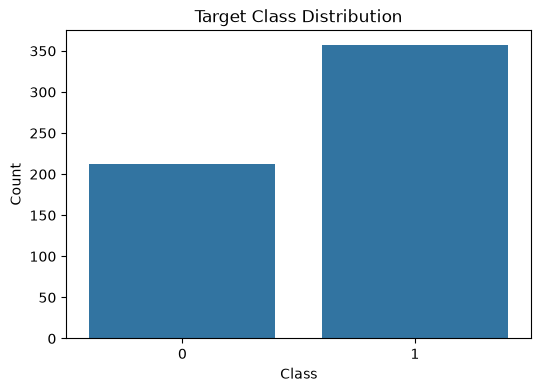

In [24]:
# Target Distribution Visualization
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### Observation

The target variable contains two classes representing a binary classification problem.

The dataset shows the distribution of malignant and benign cases. The classes are reasonably balanced, therefore no additional class balancing technique is required at this stage.

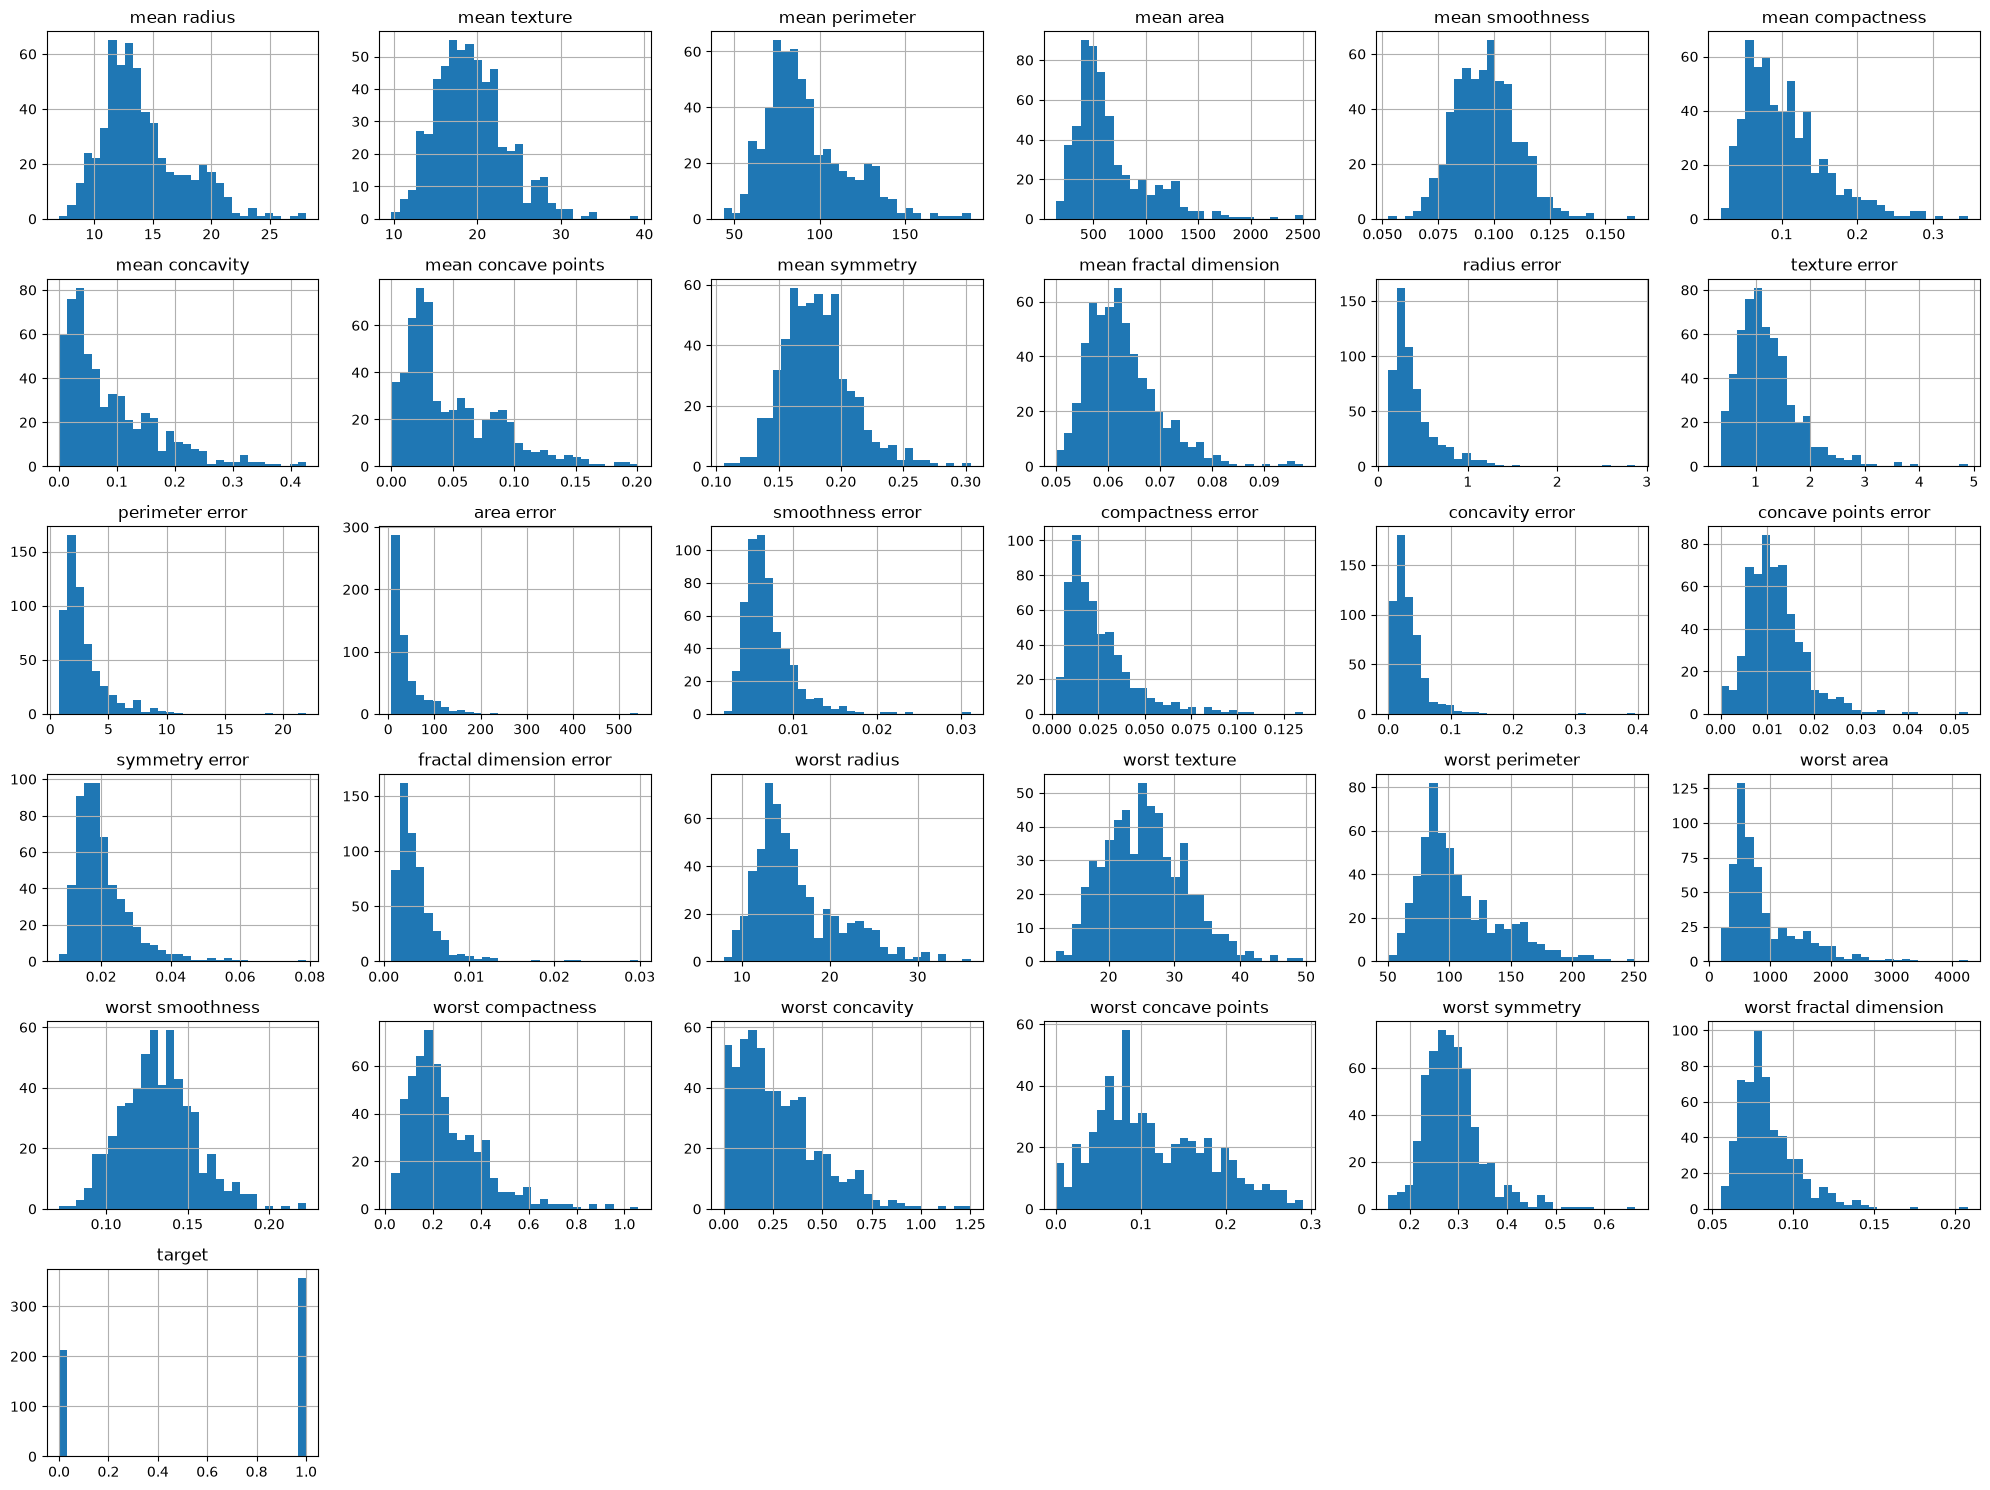

In [25]:
# Feature Distribution
df.hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

### Observation

The feature distributions show variation in scale and spread across different attributes.

Since machine learning algorithms such as SVM, Logistic Regression, and KNN are sensitive to feature scales, feature normalization will be performed during preprocessing.

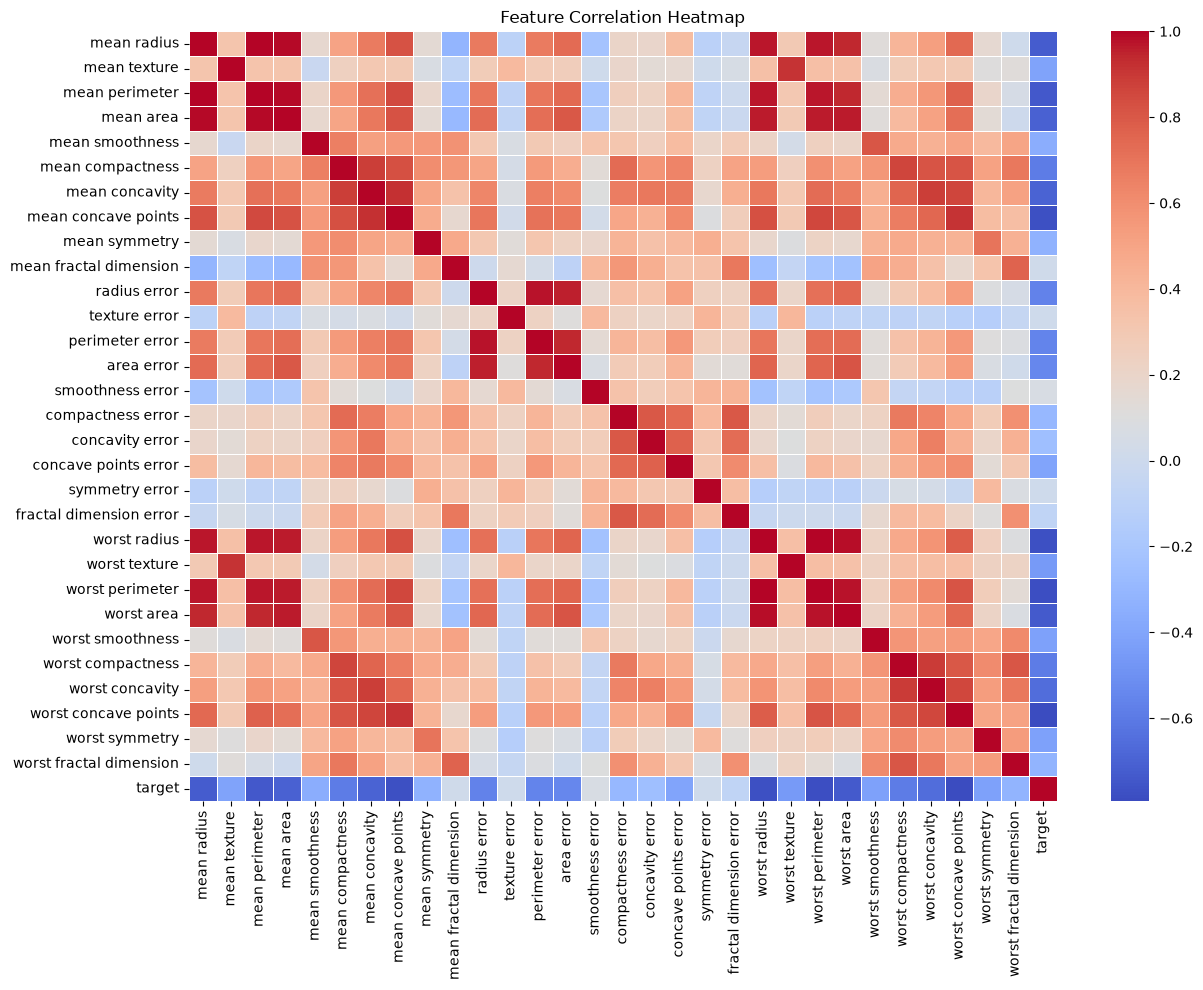

In [26]:
# CORRELATION ANALYSIS
plt.figure(figsize=(14,10))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap helps identify relationships between features.

Some features show strong correlation with each other, which is common in medical datasets. Feature scaling and model regularization techniques will help manage these relationships during training.

# Data Preprocessing

Machine learning algorithms require clean and properly transformed data.

In this section, we will:
- Separate features and target
- Split data into training and testing sets
- Apply feature scaling
- Prepare the dataset for model training

In [27]:
# SEPARATE FEATURES AND TARGET
# Features
X = df.drop("target", axis=1)

# Target
y = df["target"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (569, 30)
Target Shape: (569,)


In [28]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
# CHECK SHAPES
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


### Observation

The dataset has been divided into training and testing sets using an 80-20 split.

The `stratify=y` parameter ensures that both training and testing datasets maintain the same class distribution as the original dataset.

## Feature Scaling

Feature scaling is required because different features have different numerical ranges.

Algorithms such as:
- Logistic Regression
- KNN
- SVM

are sensitive to feature magnitude.

StandardScaler transforms features into a standard normal distribution with:
- Mean = 0
- Standard deviation = 1

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
# Fit and Transform Training Data
X_train_scaled = scaler.fit_transform(X_train)

In [34]:
# Transform Testing Data
X_test_scaled = scaler.transform(X_test)

In [35]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [36]:
# Check Scaling Result
X_train_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,...,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
1,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,...,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
2,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,...,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
3,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,...,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
4,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,...,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


In [37]:
# Verify mean and Standard Deviation
print("Mean:")
print(X_train_scaled.mean().round(2))

print("\nStandard Deviation:")
print(X_train_scaled.std().round(2))

Mean:
mean radius               -0.0
mean texture               0.0
mean perimeter            -0.0
mean area                 -0.0
mean smoothness            0.0
mean compactness          -0.0
mean concavity            -0.0
mean concave points        0.0
mean symmetry             -0.0
mean fractal dimension     0.0
radius error              -0.0
texture error             -0.0
perimeter error            0.0
area error                 0.0
smoothness error          -0.0
compactness error         -0.0
concavity error            0.0
concave points error      -0.0
symmetry error             0.0
fractal dimension error    0.0
worst radius               0.0
worst texture             -0.0
worst perimeter           -0.0
worst area                 0.0
worst smoothness           0.0
worst compactness         -0.0
worst concavity            0.0
worst concave points      -0.0
worst symmetry            -0.0
worst fractal dimension    0.0
dtype: float64

Standard Deviation:
mean radius                1

### Observation

Feature scaling has been successfully applied using StandardScaler.

The training dataset has been fitted using the scaler, and the same transformation has been applied to the testing dataset.

This prevents data leakage because the scaler learns parameters only from the training data.

# Model Training

In this section, multiple classification algorithms will be trained on the preprocessed dataset.

The purpose is to compare different machine learning approaches and identify the best-performing model based on evaluation metrics.

In [38]:
# IMPORT CLASSIFICATION MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

In [39]:
# CREATE A MODEL DICTIONARY
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


In [40]:
# TRAIN MODELS
trained_models = {}

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    trained_models[name] = model

    print(f"{name} trained successfully ✅")

Logistic Regression trained successfully ✅
KNN trained successfully ✅
Decision Tree trained successfully ✅
Naive Bayes trained successfully ✅
SVM trained successfully ✅
Random Forest trained successfully ✅
AdaBoost trained successfully ✅
Gradient Boosting trained successfully ✅


In [41]:
# CHECK STORED MODELS
trained_models.keys()

dict_keys(['Logistic Regression', 'KNN', 'Decision Tree', 'Naive Bayes', 'SVM', 'Random Forest', 'AdaBoost', 'Gradient Boosting'])

### Observation

All selected classification algorithms have been successfully trained.

The trained models are stored inside a dictionary, which makes it easier to:
- Compare models
- Generate predictions
- Integrate the models into the Streamlit application

In [42]:
# GENERATE PREDICTIONS
predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(
        X_test_scaled
    )

print("Predictions generated successfully ✅")

Predictions generated successfully ✅


In [43]:
# CHECK PREDICTION EXAMPLES
predictions["Random Forest"][:10]

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

### Observation

Predictions have been generated for all trained models.

These predictions will be used in the next phase to calculate:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC Curve
- AUC Score

# Model Evaluation

After training the models, the next step is to evaluate their performance using multiple classification metrics.

Instead of relying only on accuracy, we will compare the models using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

These metrics provide a more comprehensive understanding of each model's performance.

In [44]:
# Import Evaluation Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [45]:
# Create Evaluation Table
results = []

In [46]:
# Evaluate All Models
for name, model in trained_models.items():

    y_pred = model.predict(X_test_scaled)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC AUC": roc_auc_score(y_test, y_prob)

    })

In [47]:
# Create Comparison DataFrame
results_df = pd.DataFrame(results)

In [48]:
# Sort Models
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

In [49]:
# Sort Results
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
2,KNN,0.956140,0.958904,0.972222,0.965517,0.978836
3,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993882
4,AdaBoost,0.956140,0.946667,0.986111,0.965986,0.982474
5,Gradient Boosting,0.956140,0.946667,0.986111,0.965986,0.990741
6,Naive Bayes,0.929825,0.944444,0.944444,0.944444,0.986772
7,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675


In [50]:
# Round Values
results_df.iloc[:,1:] = results_df.iloc[:,1:].round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
1,SVM,0.9825,0.9861,0.9861,0.9861,0.9950
2,KNN,0.9561,0.9589,0.9722,0.9655,0.9788
3,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9939
4,AdaBoost,0.9561,0.9467,0.9861,0.9660,0.9825
5,Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9907
6,Naive Bayes,0.9298,0.9444,0.9444,0.9444,0.9868
7,Decision Tree,0.9123,0.9559,0.9028,0.9286,0.9157


### Observation

The comparison table provides the performance of all classification models on the testing dataset.

The models are sorted based on accuracy, making it easier to identify the top-performing algorithm.

Additional metrics such as Precision, Recall, F1 Score, and ROC-AUC provide a more balanced evaluation than accuracy alone.

In [52]:
# Best Model
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

Logistic Regression


In [53]:
# Best Accuracy
best_accuracy = results_df.iloc[0]["Accuracy"]

print(best_accuracy)

0.9825


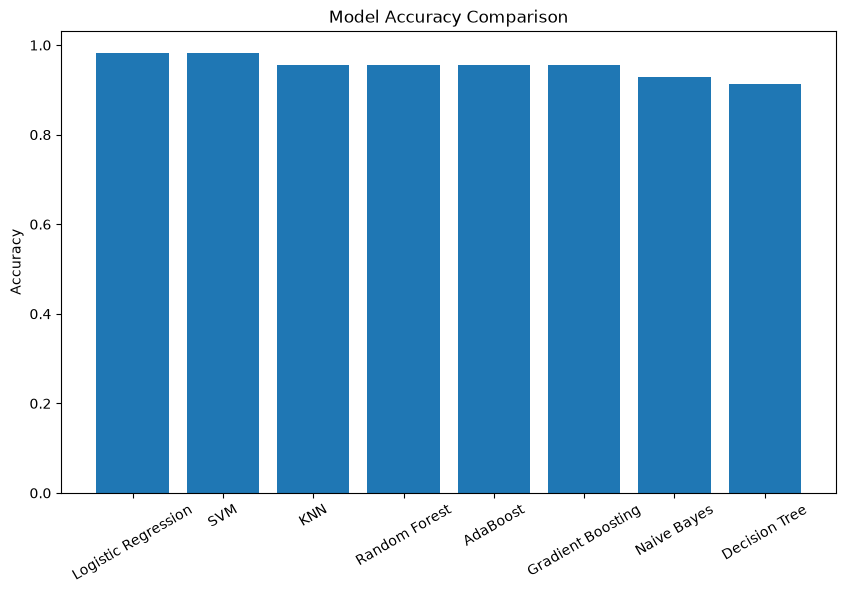

In [54]:
# Bar Chart Comparison
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=30)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

### Observation

The bar chart provides a quick comparison of model accuracy.

It helps visualize performance differences and makes it easier to identify the best-performing classifier.

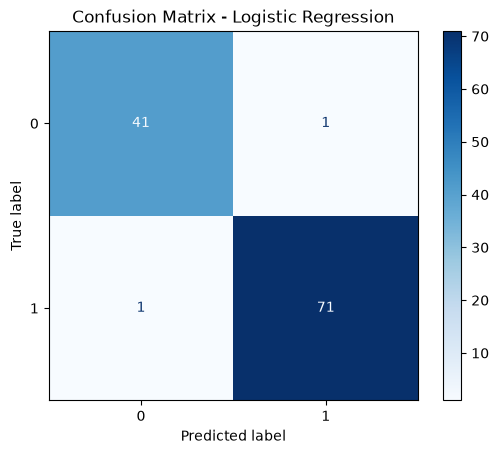

In [55]:
# Confusion Matrix
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

### Observation

The confusion matrix shows the number of correctly and incorrectly classified samples.

A higher number of values along the diagonal indicates better classification performance.

In [56]:
# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



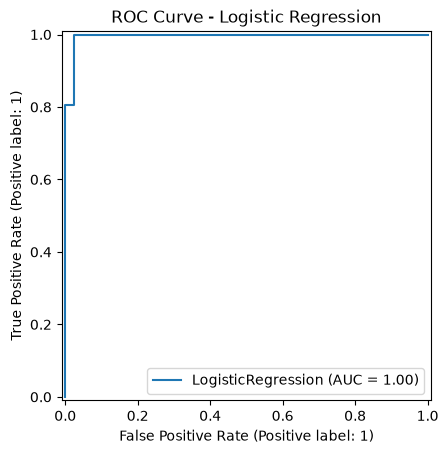

In [57]:
# ROC Curve
RocCurveDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

plt.title(f"ROC Curve - {best_model_name}")

plt.show()

### Observation

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate.

A curve closer to the top-left corner indicates better classification performance.

The ROC-AUC score quantifies this performance, where values closer to 1 represent a stronger classifier.

In [58]:
# Feature Importance (Tree-Based Models Only)
tree_models = [
    "Decision Tree",
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting"
]

print(tree_models)

['Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting']


# Model Finalization

In this section, we will:

- Visualize feature importance
- Select the best-performing model
- Save the trained model
- Reload the saved model
- Make sample predictions

In [59]:
# Feature Importance
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    feature_importance.head(10)

In [61]:
# Plot Feature Importance
if hasattr(best_model, "feature_importances_"):

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feature_importance.head(10),
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top 10 Important Features - {best_model_name}")

    plt.show()

### Observation

The graph highlights the ten most influential features used by the best-performing tree-based model.

Features with higher importance contribute more significantly to the model's prediction process.

In [62]:
# Import Joblib
import joblib

In [63]:
# Save Best Model
joblib.dump(
    best_model,
    "../saved_models/model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [64]:
# Load Saved Model
loaded_model = joblib.load(
    "../saved_models/model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [65]:
# Test Loaded Model
loaded_model.predict(X_test_scaled[:5])

array([0, 1, 0, 1, 0])

In [66]:
# Actual Values
y_test.iloc[:5].values

array([0, 1, 0, 1, 0])

In [67]:
# Make One Sample Prediction
sample = X_test_scaled.iloc[[0]]

prediction = loaded_model.predict(sample)

prediction

array([0])

In [68]:
# Convert Prediction into Label
label = {
    0: "Malignant",
    1: "Benign"
}

print("Prediction:", label[prediction[0]])

Prediction: Malignant


In [69]:
# Save Results Table
results_df.to_csv(
    "../saved_models/model_comparison.csv",
    index=False
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


### Conclusion

The complete machine learning pipeline has been successfully implemented.

The workflow included:

- Dataset loading
- Data exploration
- Data preprocessing
- Model training
- Performance evaluation
- Model comparison
- Feature importance analysis
- Best model selection
- Model persistence

The saved model and comparison results are now ready to be integrated into the Streamlit application.